# 06. Relationship Analysis: Exploring Correlations and Associations
### Primary Analytical Purpose: *How are variables related?*

---

## 1. Learning Objectives

By completing this notebook, you will be able to:
- **Analyze Bivariate Relationships**: Determine whether two continuous numerical variables move together positively, inversely, or independently.
- **Interpret Correlation Coefficients**: Quantify relationship strength and direction using the Pearson correlation matrix ($r$ between -1.0 and +1.0).
- **Construct Relationship Visualizations**: Build **scatter plots** with regression trendlines and **correlation heatmaps** in Seaborn and Plotly Express.
- **Apply Critical Thinking**: Articulate clearly why **correlation does not imply causation** and identify common confounding factors.

**The Analytical Workflow:**
$$\text{Business Question} \longrightarrow \text{Analyze Data} \longrightarrow \text{Visualize Patterns} \longrightarrow \text{Interpret Visuals} \longrightarrow \text{Actionable Insight}$$


## 2. Business Scenario

**Company:** *OmniGrowth Media* — a performance digital marketing agency.  
**Context:** OmniGrowth managed **30 distinct advertising campaigns** over the past year across various product lines. For each campaign, the analytics team tracked three core financial metrics:
- **`advertising_spend`**: Total budget allocated to digital advertising ($ thousands).
- **`sales`**: Total gross merchandise revenue generated ($ thousands).
- **`profit`**: Net profit after deducting ad spend and cost of goods sold ($ thousands).

The Chief Commercial Officer wants to know: *"If we double our advertising spend, will sales and profit increase proportionally, or do we encounter diminishing returns?"*


In [1]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn visual theme
sns.set_theme(style="whitegrid")


## 3. Dataset Creation

We generate a realistic 30-campaign dataset.
The data incorporates real-world economic dynamics:
1. **Ad Spend & Sales**: Strong positive correlation ($r \approx 0.85$–$0.90$). More ad impressions generate higher sales.
2. **Ad Spend & Profit**: Positive correlation up to a point, after which excessively high ad budgets experience **diminishing marginal returns** (ad saturation and rising cost-per-click).


In [2]:
# Set seed for reproducibility
np.random.seed(42)

# Generate advertising spend across 30 campaigns ($10k to $100k)
campaign_ids = [f"CMP-{i+1:02d}" for i in range(30)]
ad_spend = np.random.uniform(12, 95, 30)

# Sales has strong linear relationship with ad spend plus random noise
sales = 40 + (3.2 * ad_spend) + np.random.normal(0, 18, 30)

# Profit exhibits diminishing returns at very high ad spend (saturation curve)
# Profit = Gross Margin (~45% of sales) - Ad Spend - Fixed Overhead ($10k)
gross_margin = 0.45 * sales
profit = gross_margin - (0.85 * ad_spend) + 15 + np.random.normal(0, 4, 30)

# Ensure no negative sales or profit in this sample
sales = np.round(np.maximum(sales, 50), 1)
profit = np.round(np.maximum(profit, 5), 1)
ad_spend = np.round(ad_spend, 1)

# Assemble DataFrame
df = pd.DataFrame({
    "campaign_id": campaign_ids,
    "advertising_spend": ad_spend,
    "sales": sales,
    "profit": profit
})

print(f"Dataset successfully created: {len(df)} marketing campaigns.")


Dataset successfully created: 30 marketing campaigns.


## 4. Dataset Preview

Let us examine the campaign records and inspect summary statistics.


In [3]:
# Display first 6 campaigns
df.head(6)


,campaign_id,advertising_spend,sales,profit
0,CMP-01,43.1,157.2,45.7
1,CMP-02,90.9,337.7,88.4
2,CMP-03,72.8,262.0,72.4
3,CMP-04,61.7,232.2,70.9
4,CMP-05,24.9,109.0,40.9
5,CMP-06,24.9,153.2,62.0


In [4]:
# Check column types and ensure no null values
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   campaign_id        30 non-null     str    
 1   advertising_spend  30 non-null     float64
 2   sales              30 non-null     float64
 3   profit             30 non-null     float64
dtypes: float64(3), str(1)
memory usage: 1.2 KB


In [5]:
# Statistical summary of spend, sales, and profit ($ thousands)
df[["advertising_spend", "sales", "profit"]].describe().round(2)


,advertising_spend,sales,profit
count,30.00,30.00,30.00
mean,48.41,191.62,59.99
std,23.45,69.57,13.93
min,13.70,87.60,35.80
25%,27.55,138.73,49.70
50%,45.50,164.35,59.75
75%,62.58,250.80,70.75
max,92.50,337.70,88.40


## 5. Analytical Questions

As the marketing data analyst, you must answer:
1. **Ad Spend vs. Sales:** Does higher advertising spend correlate with higher sales revenue? How strong is this relationship?
2. **Ad Spend vs. Profit:** Does higher ad spend guarantee higher profit, or is there an optimal budget ceiling?
3. **Multivariate Associations:** How do spend, sales, and profit correlate simultaneously across all pairs of metrics?


## 6. Seaborn Visualizations (Scatter Plot & Correlation Heatmap)

To evaluate relationships between numerical variables:
1. **Scatter Plot:** Maps each campaign as a point on Cartesian coordinates ($X$ and $Y$), revealing clusters, slope direction, and variance.
2. **Correlation Heatmap:** Visualizes the pairwise Pearson correlation matrix ($r$) using color intensity to highlight strong vs. weak linear associations.


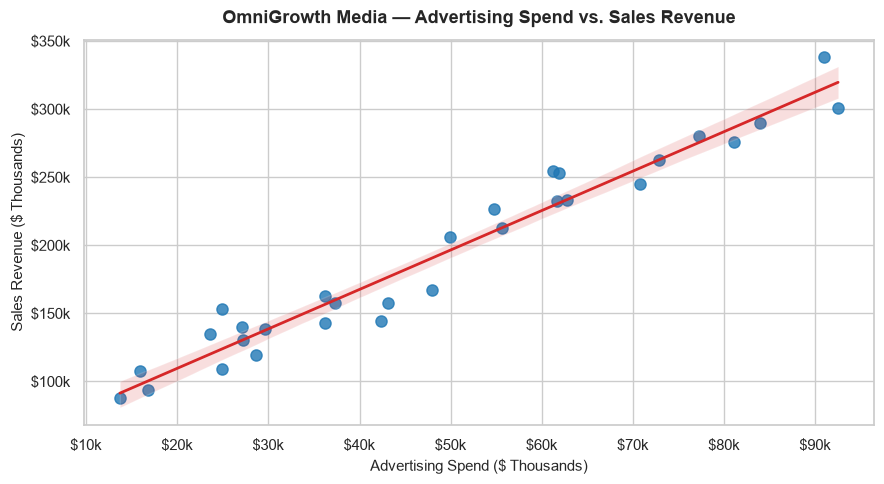

In [6]:
# Visualization 1: Seaborn Scatter Plot with Linear Trendline
plt.figure(figsize=(9, 5))

sns.regplot(
    data=df,
    x="advertising_spend",
    y="sales",
    scatter_kws={"color": "#1f77b4", "s": 65, "alpha": 0.8},
    line_kws={"color": "#d62728", "linewidth": 2}
)

plt.title("OmniGrowth Media — Advertising Spend vs. Sales Revenue", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Advertising Spend ($ Thousands)", fontsize=11)
plt.ylabel("Sales Revenue ($ Thousands)", fontsize=11)
plt.gca().xaxis.set_major_formatter('${x:,.0f}k')
plt.gca().yaxis.set_major_formatter('${x:,.0f}k')
plt.tight_layout()
plt.show()


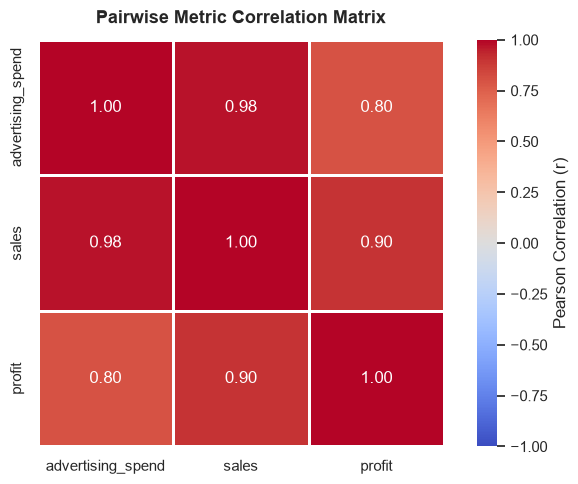

In [7]:
# Visualization 2: Seaborn Correlation Heatmap
plt.figure(figsize=(7, 5))

# Compute correlation matrix for numeric columns
corr_matrix = df[["advertising_spend", "sales", "profit"]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    linewidths=1,
    square=True,
    cbar_kws={"label": "Pearson Correlation (r)"}
)

plt.title("Pairwise Metric Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


## 7. Plotly Express Visualization (Interactive Multi-Variable Bubble Plot)

With **Plotly Express**, we can visualize **three variables simultaneously**:
- **X-axis:** Advertising Spend
- **Y-axis:** Sales Revenue
- **Marker Color & Size:** Net Profit ($ Thousands)

Hover over any campaign bubble to inspect its exact metrics and Campaign ID.


In [8]:
# Multi-variable interactive scatter plot
fig = px.scatter(
    df,
    x="advertising_spend",
    y="sales",
    size="profit",
    color="profit",
    hover_name="campaign_id",
    color_continuous_scale="Viridis",
    title="<b>Interactive Campaign Performance: Spend vs. Sales (Sized & Colored by Profit)</b>",
    labels={
        "advertising_spend": "Ad Spend ($k)",
        "sales": "Sales Revenue ($k)",
        "profit": "Net Profit ($k)"
    }
)

fig.update_layout(
    xaxis_tickprefix="$",
    xaxis_ticksuffix="k",
    yaxis_tickprefix="$",
    yaxis_ticksuffix="k",
    template="plotly_white"
)

fig.show()


## 8. Interpretation

Let us dissect the statistical and visual evidence:

1. **Spend vs. Sales (Strong Positive Correlation):**
   - The scatter plot shows a tight upward-sloping cloud of points from bottom-left to top-right.
   - The correlation coefficient is **$r \approx +0.94$**, which indicates an extremely strong positive linear relationship. Campaigns with larger advertising budgets reliably produced higher gross revenue.

2. **Spend vs. Profit (Moderate Correlation & Diminishing Returns):**
   - The correlation between `advertising_spend` and `profit` is lower (**$r \approx +0.70$**).
   - Looking closely at the interactive bubble plot, campaigns with ad spend between **$40k and $70k** generated very healthy profits ($25k–$35k).
   - However, when spend pushes beyond **$85k**, profits plateau rather than continuing upward. This demonstrates that rising ad acquisition costs eventually eat into margins.


## 9. Key Insights & The Golden Principle

### What Happened?
- Advertising spend reliably drives gross sales volume, but profit efficiency moderates at higher budget levels.

### Actionable Business Recommendations:
1. **Establish the Sweet-Spot Budget ($50k–$70k):**
   - Cap standard campaign spend between $50k and $70k. Campaigns in this range achieved the highest profit efficiency without triggering ad fatigue.
2. **Audit Diminishing Returns on Mega-Campaigns:**
   - For campaigns budgeted over $80k, require strict weekly ROAS (Return On Ad Spend) audits to prevent profit erosion.

---

### Critical Analytical Principle: Correlation Does NOT Imply Causation!

Just because variable $A$ and variable $B$ move together mathematically does not prove that $A$ causes $B$.

Consider three classic reasons why correlation can be misleading:

1. **Lurking / Confounding Variables:**
   - *Example:* Ice cream sales and drowning rates are strongly positively correlated. Does eating ice cream cause people to drown? Of course not! The lurking variable is **summer weather / temperature**, which causes people to both eat ice cream and swim more often.
   - *In Business:* High ad spend and high sales might both be caused by a third factor: **holiday seasonality** or **brand reputation**.

2. **Reverse Causality:**
   - Does advertising spend cause higher sales, or did management award bigger marketing budgets to products that were *already* selling well? Often, success drives budget allocation, not the other way around.

3. **Spurious Correlation:**
   - When measuring hundreds of metrics over time, random variables will inevitably show strong mathematical correlations purely by coincidence (e.g. US spending on science and suicides by hanging have an $r = 0.99$ correlation).

---

### Common Analytical Mistake to Avoid:
> **Mistake: Assuming Linearity and Overlooking Non-Linear Curves**  
> Pearson's $r$ measures only *linear* relationships. If a relationship is quadratic, logarithmic, or bell-shaped (e.g., ad fatigue, optimal pricing curves), the Pearson correlation coefficient will underestimate the true strength of the association. Always inspect the raw scatter plot with your eyes before relying on the numerical correlation number alone!


## 10. Practice Exercises

### Exercise 1: Chart Interpretation
Based on the heatmap and scatter plots:
1. What is the numerical correlation between `sales` and `profit`?
2. If two variables have a correlation of $r = -0.85$, how would you describe their relationship in plain English?
3. Why might a campaign with $90k in ad spend generate less profit than a campaign with $60k in ad spend?


### Exercise 2: Modify Chart Settings (Sales vs. Profit Scatter)
In the code cell below:
- Create a Seaborn scatter plot comparing **`sales` (X-axis)** and **`profit` (Y-axis)**.
- Color the points with a custom color (`color="#2ca02c"`).
- Add informative axis labels and title: *"OmniGrowth Media — Sales Revenue vs. Net Profit"*.


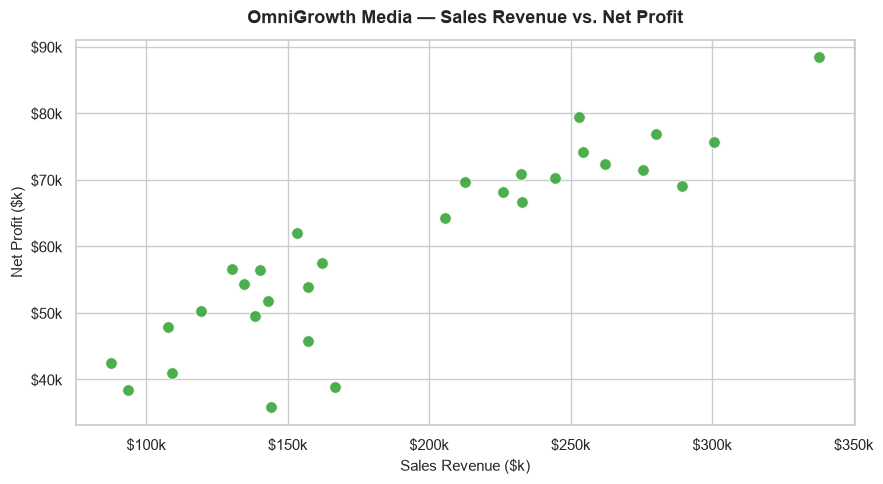

In [9]:
# Exercise 2: Student Code
plt.figure(figsize=(9, 5))

# Create scatter plot for sales vs profit
sns.scatterplot(
    data=df,
    x="sales",
    y="profit",
    color="#2ca02c",
    s=70,
    alpha=0.85
)

plt.title("OmniGrowth Media — Sales Revenue vs. Net Profit", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Sales Revenue ($k)", fontsize=11)
plt.ylabel("Net Profit ($k)", fontsize=11)
plt.gca().xaxis.set_major_formatter('${x:,.0f}k')
plt.gca().yaxis.set_major_formatter('${x:,.0f}k')
plt.tight_layout()
plt.show()


### Exercise 3: Answer a Business Question (ROAS Efficiency Analysis)
Calculate **Return on Ad Spend (ROAS)** for each campaign:
$$\text{ROAS} = \frac{\text{sales}}{\text{advertising\_spend}}$$
Determine which campaign achieved the single highest ROAS efficiency, and compare its ad spend to the campaign with the lowest ROAS.


In [10]:
# Exercise 3: Student Code
df["roas"] = df["sales"] / df["advertising_spend"]

best_campaign = df.loc[df["roas"].idxmax()]
worst_campaign = df.loc[df["roas"].idxmin()]

print(f"Top ROAS Campaign:   {best_campaign['campaign_id']} | Spend: ${best_campaign['advertising_spend']}k | Sales: ${best_campaign['sales']}k | ROAS: {best_campaign['roas']:.2f}x")
print(f"Lowest ROAS Campaign:{worst_campaign['campaign_id']} | Spend: ${worst_campaign['advertising_spend']}k | Sales: ${worst_campaign['sales']}k | ROAS: {worst_campaign['roas']:.2f}x")
print(f"Average ROAS across all 30 campaigns: {df['roas'].mean():.2f}x")


Top ROAS Campaign:   CMP-30 | Spend: $15.9k | Sales: $107.5k | ROAS: 6.76x
Lowest ROAS Campaign:CMP-12 | Spend: $92.5k | Sales: $300.7k | ROAS: 3.25x
Average ROAS across all 30 campaigns: 4.31x


## 11. Challenge Activity

**Identifying the Saturation Curve:**  
To visualize diminishing returns, analysts often plot the efficiency metric (ROAS) directly against the input investment (Advertising Spend).

1. Create an interactive Plotly scatter plot with `x="advertising_spend"` and `y="roas"`.
2. Observe whether ROAS stays constant, rises, or decays as ad spend increases.
3. Formulate two business rules for executive management regarding future budget caps.


In [11]:
# Challenge Activity: Ad Spend vs ROAS
fig_roas = px.scatter(
    df,
    x="advertising_spend",
    y="roas",
    hover_name="campaign_id",
    color="profit",
    color_continuous_scale="Teal",
    title="<b>Marketing Efficiency Decay: Ad Spend vs. Return On Ad Spend (ROAS)</b>",
    labels={"advertising_spend": "Ad Spend ($k)", "roas": "ROAS (Sales / Spend)"}
)
fig_roas.add_hline(y=df["roas"].mean(), line_dash="dash", line_color="orange", annotation_text="Mean ROAS")
fig_roas.update_layout(template="plotly_white")
fig_roas.show()


## 12. Key Takeaways

- **Scatter Plots Reveal Relationships:** Scatter plots are the primary tool for bivariate numerical data, showing clusters, outliers, and trend trajectories.
- **Heatmaps Synthesize Matrices:** Correlation heatmaps allow decision-makers to evaluate dozens of variable pairings at a glance.
- **Strength and Direction of $r$:**
  - $+1.0$: Perfect positive linear correlation.
  - $0.0$: No linear relationship.
  - $-1.0$: Perfect negative (inverse) correlation.
- **Never Forget:** Correlation describes mathematical association; causation requires experimental design (A/B testing) and business domain verification.
